In [3]:
import networkx as nx
# Open graphMl file

graph : nx.Graph = nx.read_graphml('data/simi_graph.graphml').to_undirected()
graph

In [2]:
len(graph.edges)/len(graph.nodes)

5.716598040607695

In [ ]:
list(graph.nodes(data=True))[:1]

[('0',
  {'label': 'painful-quandary',
   'community': 25,
   'Eccentricity': 23.0,
   'Closeness Centrality': 0.10471952366029458,
   'Harmonic Closeness Centrality': 0.11492404429871152,
   'Betweenness Centrality': 915725.8981014584,
   'size': 43.64179,
   'r': 92,
   'g': 102,
   'b': 187,
   'x': -3214.0505,
   'y': 11272.651})]

In [30]:
# Get the edge list into a torch tensor
import torch
embedding = torch.nn.Embedding(len(graph.nodes), 16)
embedding.weight.data = torch.rand([len(graph.nodes), 16])
embedding


Embedding(28172, 16)

In [31]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
X = embedding.weight.data.numpy()
pca = PCA(n_components=2)
components = pca.fit_transform(X)
components[5]

array([-0.5150579 , -0.12481831], dtype=float32)

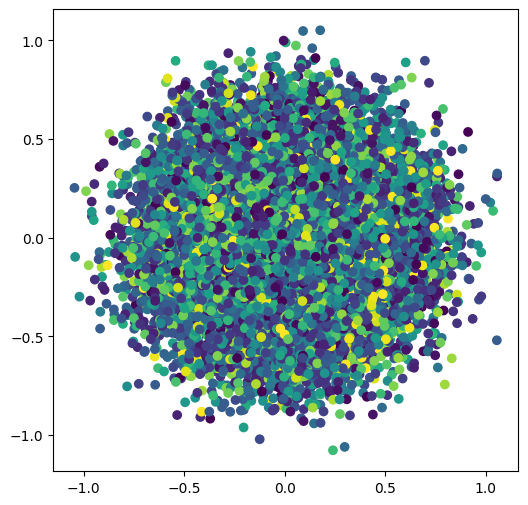

In [32]:
#Visualize the embedding 
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
def visualize_emb(emb_input : torch.nn.Embedding,graph_input :nx.Graph, epoch=None, loss=None, accuracy= None):
  X = emb_input.weight.data.numpy()
  pca = PCA(n_components=2)
  components = pca.fit_transform(X)
  plt.figure(figsize=(6, 6))
  nodes_coord_x = []
  nodes_coord_y = []
  nodes_colors = []
  for idx,node in enumerate(graph_input.nodes(data=True)):
    nodes_coord_x.append(components[idx][0])
    nodes_coord_y.append(components[idx][1])
    nodes_colors.append(node[1]["community"])
  plt.scatter(nodes_coord_x, nodes_coord_y, c=nodes_colors)
  if epoch is not None and loss is not None and accuracy is not None:
    plt.xlabel((f'Epoch: {epoch}, Loss: {loss} \n'
                       f'Accuracy: {accuracy}% \n'),
                       fontsize=16)
  plt.show()

# Visualize the initial random embeddding
visualize_emb(embedding,graph)

In [33]:
import torch
import torch_geometric
import torch_geometric.utils
data_graph = torch_geometric.utils.from_networkx(graph)
data_graph

Data(x=[28172], edge_index=[2, 322096], y=[28172], label=[28172], community=[28172], Eccentricity=[28172], Closeness Centrality=[28172], Harmonic Closeness Centrality=[28172], Betweenness Centrality=[28172], size=[28172], r=[28172], g=[28172], b=[28172], weight=[322096], id=[322096])

In [46]:
neg_edge_index = torch_geometric.utils.negative_sampling(
    edge_index=data_graph.edge_index,
    num_nodes=data_graph.num_nodes,
    num_neg_samples=500000,
    method='sparse',
    force_undirected=True
)
neg_edge_index.shape

torch.Size([2, 500000])

In [47]:
pos_edge_index = data_graph.edge_index
pos_edge_index.shape

torch.Size([2, 322096])

### Training on PCA

In [43]:

def create_node_emb(num_node=34, embedding_dim=16):
  # TODO: Implement this function that will create the node embedding matrix.
  # A torch.nn.Embedding layer will be returned. You do not need to change
  # the values of num_node and embedding_dim. The weight matrix of returned
  # layer should be initialized under uniform distribution.

  emb = None

  ############# Your code here ############
  emb = torch.nn.Embedding(num_embeddings=num_node,embedding_dim=embedding_dim)
  emb.weight.data = torch.rand([num_node,embedding_dim])
  #########################################

  return emb

In [51]:
from torch.optim import SGD
import torch.nn as nn
import time
def accuracy(pred: torch.Tensor, label: torch.LongTensor):
  # TODO: Implement the accuracy function. This function takes the
  # pred tensor (the resulting tensor after sigmoid) and the label
  # tensor (torch.LongTensor). Predicted value greater than 0.5 will
  # be classified as label 1. Else it will be classified as label 0.
  # The returned accuracy should be rounded to 4 decimal places.
  # For example, accuracy 0.82956 will be rounded to 0.8296.

  accu = 0.0

  ############# Your code here ############
  pred_rounded = torch.round(pred)
  accu = torch.round(torch.mean(torch.ones(label.shape)-torch.abs(label-pred_rounded)),decimals=4)
  #########################################

  return accu


def train(emb: torch.nn.Embedding, loss_fn: torch.nn.BCELoss, sigmoid : torch.nn.Sigmoid,
          train_label: torch.Tensor, train_edge: torch.Tensor):
  # TODO: Train the embedding layer here. You can also change epochs and
  # learning rate. In general, you need to implement:
  # (1) Get the embeddings of the nodes in train_edge
  # (2) Dot product the embeddings between each node pair
  # (3) Feed the dot product result into sigmoid
  # (4) Feed the sigmoid output into the loss_fn
  # (5) Print both loss and accuracy of each epoch
  # (6) Update the embeddings using the loss and optimizer
  # (as a sanity check, the loss should decrease during training)

  epochs = 5000
  learning_rate = 0.3

  optimizer = SGD(emb.parameters(), lr=learning_rate, momentum=0.9)

  for i in range(epochs):
    ############# Your code here ############
    # Prediction (Forward)
    optimizer.zero_grad()# Reset gradients 
    embedded_nodes_start = emb(train_edge[0])
    embedded_nodes_start = embedded_nodes_start.reshape(embedded_nodes_start.shape[0],1,embedded_nodes_start.shape[1])
    embedded_nodes_end = emb(train_edge[1])
    embedded_nodes_end = embedded_nodes_end.reshape(embedded_nodes_end.shape[0],embedded_nodes_end.shape[1],1)
    embedded_nodes = torch.matmul(embedded_nodes_start,embedded_nodes_end).squeeze(1).squeeze(1) # Dot product
    pred = sigmoid(embedded_nodes)
    # Update parameters (Backward)
    loss = loss_fn(pred,train_label)
    loss.backward()
    optimizer.step()
    # Accuracy calculus
    accu = accuracy(pred,train_label)
    
    if i % 10 == 0:
      print(f"Epoch {i}, Loss: {loss.item()}, Accuracy: {accu}")
    #########################################

emb = create_node_emb(len(graph.nodes), 64)
loss_fn = nn.BCELoss()
sigmoid = nn.Sigmoid()

print("pos_edge_index", pos_edge_index.shape)

# Generate the positive and negative labels
pos_label = torch.ones(pos_edge_index.shape[1], )
neg_label = torch.zeros(neg_edge_index.shape[1], )

# Concat positive and negative labels into one tensor
train_label = torch.cat([pos_label, neg_label], dim=0)

# Concat positive and negative edges into one tensor
# Since the network is very small, we do not split the edges into val/test sets
train_edge = torch.cat([pos_edge_index, neg_edge_index], dim=1)
print("train edge shape", train_edge.shape)
train(emb, loss_fn, sigmoid, train_label, train_edge)

pos_edge_index torch.Size([2, 322096])
train edge shape torch.Size([2, 822096])
Epoch 0, Loss: 27.46703338623047, Accuracy: 0.3917999863624573
Epoch 10, Loss: 27.357295989990234, Accuracy: 0.3917999863624573
Epoch 20, Loss: 27.155794143676758, Accuracy: 0.3917999863624573
Epoch 30, Loss: 26.90461540222168, Accuracy: 0.3917999863624573
Epoch 40, Loss: 26.64292335510254, Accuracy: 0.3917999863624573
Epoch 50, Loss: 26.378808975219727, Accuracy: 0.3917999863624573
Epoch 60, Loss: 26.111839294433594, Accuracy: 0.3917999863624573
Epoch 70, Loss: 25.8648681640625, Accuracy: 0.3917999863624573
Epoch 80, Loss: 25.59638214111328, Accuracy: 0.3917999863624573
Epoch 90, Loss: 25.339075088500977, Accuracy: 0.3917999863624573
Epoch 100, Loss: 25.075529098510742, Accuracy: 0.3917999863624573
Epoch 110, Loss: 24.824302673339844, Accuracy: 0.3917999863624573
Epoch 120, Loss: 24.56861686706543, Accuracy: 0.3917999863624573
Epoch 130, Loss: 24.316009521484375, Accuracy: 0.3917999863624573
Epoch 140, Los

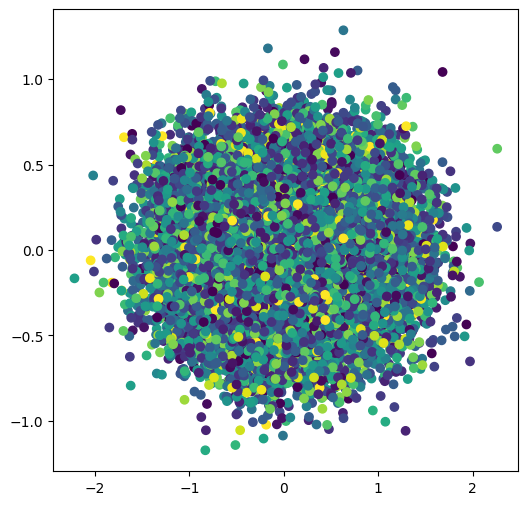

In [ ]:
visualize_emb(emb, graph)  